# Baseline Dataset EDA (Phase 1)

Exploratory analysis of the four baseline corpora before Phase 2 fine-tuning.

**Scope:** inspection samples only (`INSPECTION_SAMPLE_SIZE` in `config.py`). Full training corpora load in Phase 2. Spanish is **not** in training — XLM-R transfers zero-shot; peninsular ES validation happens on study corpora in Phase 2.

| Section | Question answered |
|---------|-------------------|
| Corpus summary | Schema, size, label balance, duplicates |
| Label distributions | Is each corpus binary and balanced? |
| Text lengths | Microblog length profile by language |
| Token lengths | What share exceeds `max_length=256` for XLM-R? |
| Quality audit | Empty text, duplicates, harmonization flags |

Logic lives in `src/data/baseline.py` and `src/data/eda.py`; this notebook is visualization only.

**How to run:** Kernel → Restart & Run All. Each markdown cell below explains what the next code cell does and why.

### Setup — imports and configuration

We add `src/` to the Python path so the notebook can import project modules (`config`, `baseline`, `eda`).

`importlib.reload()` forces Jupyter to pick up recent edits to those files without restarting the kernel.

The printed constants confirm which model (`xlm-roberta-base`), sample cap, and token limit the rest of the notebook will use.

In [18]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from IPython.display import Markdown, display
from transformers import AutoTokenizer

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import config
import data.baseline as baseline
import data.eda as eda

importlib.reload(config)
importlib.reload(baseline)
importlib.reload(eda)

from config import BASE_MODEL_ID, INSPECTION_SAMPLE_SIZE, MAX_SEQUENCE_LENGTH
from data.baseline import BASELINE_DATASETS, load_baseline_dataset, sample_rows
from data.eda import (
    build_corpus_summary_row,
    build_eda_frame,
    corpus_summaries_to_frame,
    label_distribution,
    summarize_corpus,
    token_length_stats,
)

sns.set_theme(style="whitegrid", palette="muted")
LANG_COLORS = {"zh": "#e74c3c", "en": "#3498db", "es": "#2ecc71"}

print(f"Project root: {PROJECT_ROOT}")
print(f"Inspection cap: {INSPECTION_SAMPLE_SIZE:,} rows")
print(f"Model / max tokens: {BASE_MODEL_ID} / {MAX_SEQUENCE_LENGTH}")

Project root: /home/gonza/Gonzalo/Proyectos/nlp
Inspection cap: 2,000 rows
Model / max tokens: xlm-roberta-base / 256


## 1. Load corpora

Iterate over the four datasets defined in `BASELINE_DATASETS` (2 train + 2 validation).

For each corpus we:
1. **Load** the full split, **shuffle**, then cap to `INSPECTION_SAMPLE_SIZE` — required because some corpora (e.g. weibo) are label-ordered on disk.
2. **Build an EDA frame** (`build_eda_frame`) with text, label, and length columns ready for plotting.
3. **Store** everything in `loaded` for reuse in later cells.

Load notes flag HF mirror IDs where the planned dataset ID no longer works with `datasets>=2.x`.

In [19]:
loaded: dict[str, dict[str, object]] = {}

for spec in BASELINE_DATASETS:
    print(f"Loading {spec.name} ({spec.language}, {spec.role})...")
    dataset = load_baseline_dataset(spec, max_rows=INSPECTION_SAMPLE_SIZE)
    eda_frame = build_eda_frame(
        dataset,
        text_column=spec.text_column,
        label_column=spec.label_column,
        language=spec.language,
    )
    loaded[spec.name] = {
        "spec": spec,
        "dataset": dataset,
        "eda_frame": eda_frame,
    }
    print(
        f"  -> {len(dataset):,} rows | cols: {dataset.column_names}"
        + (f"\n     note: {spec.load_note}" if spec.load_note else "")
    )

Loading weibo_senti_100k (zh, train)...
  -> 2,000 rows | cols: ['label', 'review']
Loading sentiment140 (en, train)...
  -> 2,000 rows | cols: ['sentiment', 'tweet', 'clean_tweet']
     note: Phase 1 uses 10k-row clean mirror for inspection. Phase 2 training subsamples 100k from adilbekovich/Sentiment140Twitter.
Loading tass2020 (es, train)...
  -> 1,125 rows | cols: ['sentence', 'sentiments', 'labels']
     note: Official tass2020 is not loadable via datasets>=2.x. Using TASS-derived Spanish tweet corpus as Phase 1 proxy; register for IberLEF/TASS 2020 before Phase 2 training.
Loading ChnSentiCorp (zh, validation)...
  -> 1,200 rows | cols: ['text', 'label']
     note: seamew/ChnSentiCorp uses a deprecated loading script; parquet mirror used instead.
Loading sst2 (en, validation)...
  -> 872 rows | cols: ['sentence', 'label', 'idx']


## 2. Corpus summary

Compute one summary row per dataset with `build_corpus_summary_row()` and display as a Polars table.

Key columns to read:
- **`is_binary`** — training expects two sentiment classes; multi-class corpora (e.g. TASS proxy) need filtering.
- **`positive_ratio` / `label_skew`** — distance from 50/50 balance; large skew can bias fine-tuning.
- **`char_len_p95` / `word_len_p95`** — tail length; long posts need chunking.
- **`pct_over_char_256`** — rough overflow vs. the 256-token budget (character proxy).
- **`duplicate_rate`** — repeated posts that preprocessing should deduplicate.

In [20]:
importlib.reload(eda)

summary_rows = [
    build_corpus_summary_row(
        name=name,
        role=bundle["spec"].role,
        language=bundle["spec"].language,
        hf_id=bundle["spec"].hf_id,
        frame=bundle["eda_frame"],
    )
    for name, bundle in loaded.items()
]

summary = corpus_summaries_to_frame(summary_rows)
display(summary)

name,role,language,hf_id,n_rows,is_binary,positive_ratio,label_skew,char_len_p95,word_len_p95,pct_over_char_256,duplicate_rate,empty_texts,label_counts
str,str,str,str,i64,bool,f64,f64,f64,f64,f64,f64,i64,str
"""sentiment140""","""train""","""en""","""Roh2014/sentiment140_10k_tweet…",2000,true,0.5,0.0,130.0,27.0,0.0,0.0,2,"""{'negative': 1000, 'positive':…"
"""tass2020""","""train""","""es""","""mrm8488/tass-2019""",1125,false,null,null,136.0,26.0,0.0,0.0,0,"""{'0': 474, '1': 354, '2': 157,…"
"""weibo_senti_100k""","""train""","""zh""","""dirtycomputer/weibo_senti_100k""",2000,true,0.5115,0.0115,151.0,8.0,0.0,0.0,0,"""{'0': 977, '1': 1023}"""
"""sst2""","""validation""","""en""","""nyu-mll/glue""",872,true,0.5092,0.0092,186.0,34.0,0.0,0.0,0,"""{'0': 428, '1': 444}"""
"""ChnSentiCorp""","""validation""","""zh""","""lansinuote/ChnSentiCorp""",1200,true,0.4942,0.0058,248.0,6.0,4.5,0.0183,0,"""{'0': 607, '1': 593}"""


## 3. Label distributions

Bar chart of raw label counts per corpus.

We check visually that:
- Train and validation sets are **binary** (two bars only, except the TASS proxy).
- Classes are **roughly balanced** — severe imbalance would warrant stratified sampling or class weights in Phase 2.
- **Label encoding varies** by source (integers vs. strings like `negative`/`positive`) — harmonization is required before mixing corpora.

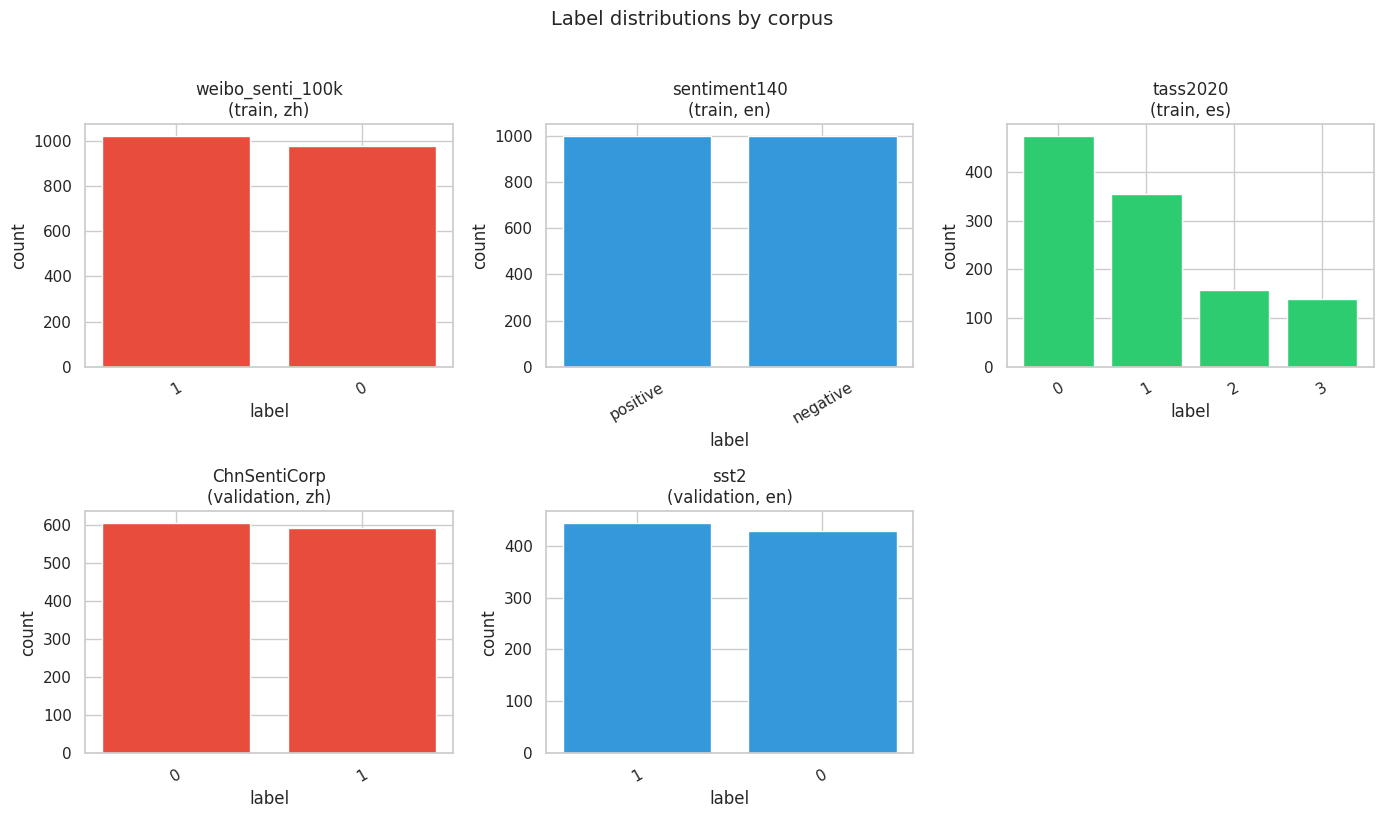

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.flatten()

for ax, (name, bundle) in zip(axes_flat, loaded.items(), strict=False):
    spec = bundle["spec"]
    frame = bundle["eda_frame"]
    dist = label_distribution(frame)
    labels = dist["label"].cast(pl.Utf8).to_list()
    counts = dist["count"].to_list()
    colors = [LANG_COLORS[spec.language]] * len(labels)

    ax.bar(labels, counts, color=colors, edgecolor="white")
    ax.set_title(f"{name}\n({spec.role}, {spec.language})")
    ax.set_xlabel("label")
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=30)

for ax in axes_flat[len(loaded) :]:
    ax.axis("off")

fig.suptitle("Label distributions by corpus", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 4. Text length distributions

Histogram of post lengths per corpus.

- **Chinese (zh):** use **character length** — no word boundaries, so word counts are misleading.
- **English / Spanish:** use **word length** as a microblog proxy.

The dashed line marks 256 (our XLM-R token budget). Posts in the right tail will need truncation or chunking in `preprocessing.py`. Reddit study corpora (Phase 2) are expected to have a much longer tail than these microblog training sets.

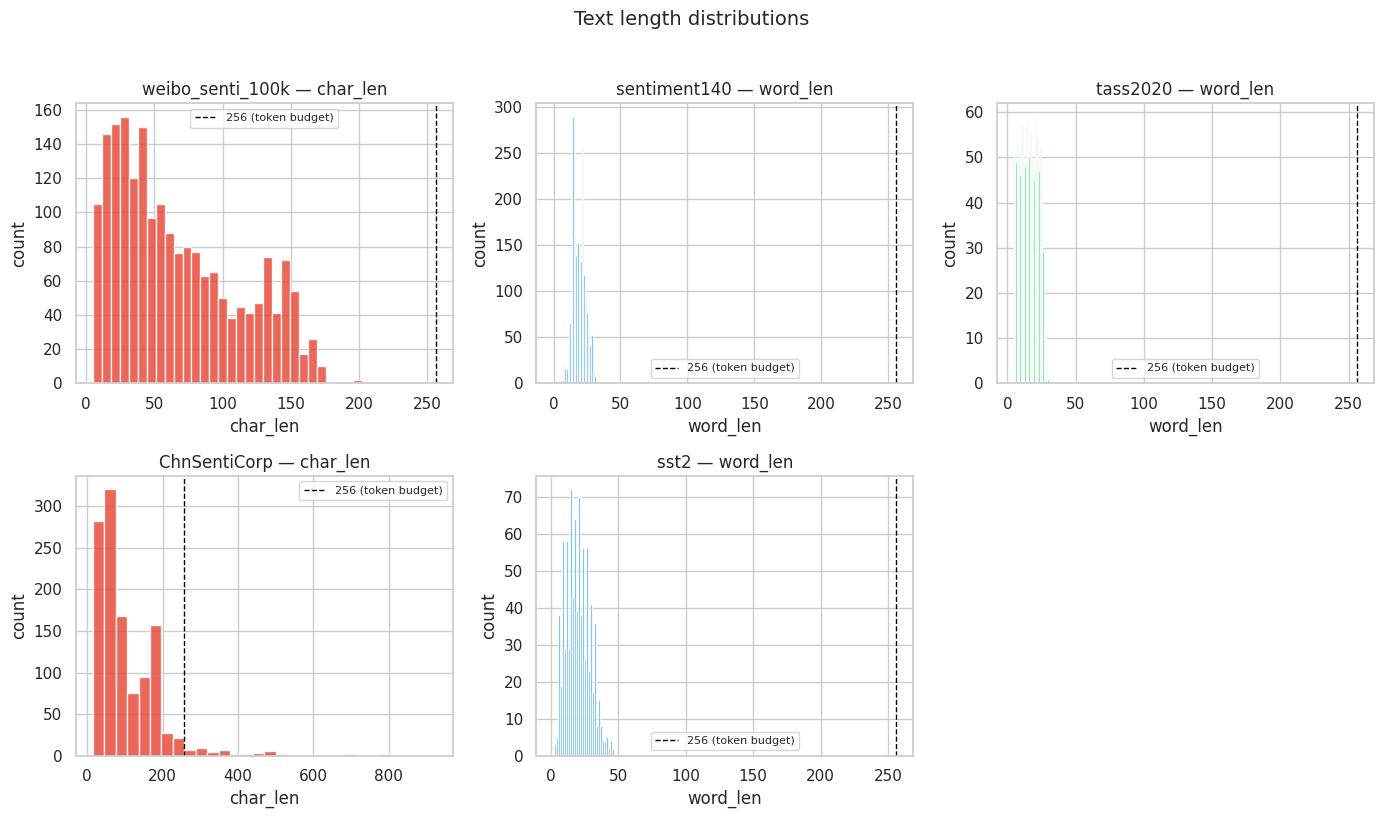

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.flatten()

for ax, (name, bundle) in zip(axes_flat, loaded.items(), strict=False):
    spec = bundle["spec"]
    frame = bundle["eda_frame"]
    metric = "char_len" if spec.language == "zh" else "word_len"
    values = frame[metric].to_list()

    ax.hist(values, bins=30, color=LANG_COLORS[spec.language], alpha=0.85)
    ax.axvline(
        MAX_SEQUENCE_LENGTH,
        color="black",
        linestyle="--",
        linewidth=1,
        label=f"{MAX_SEQUENCE_LENGTH} (token budget)",
    )
    ax.set_title(f"{name} — {metric}")
    ax.set_xlabel(metric)
    ax.set_ylabel("count")
    ax.legend(fontsize=8)

for ax in axes_flat[len(loaded) :]:
    ax.axis("off")

fig.suptitle("Text length distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 5. XLM-R token lengths (500-row sample)

Character/word counts are only a proxy. Here we tokenize a **500-row sample** with the cached `xlm-roberta-base` tokenizer to measure actual subword lengths.

This tells us:
- How many posts exceed **`MAX_SEQUENCE_LENGTH = 256`** tokens (information loss if truncated).
- Whether Chinese segmentation inflates token counts relative to English/Spanish (relevant to RQ3).

The table shows quantiles; the bar chart highlights `%` over the limit per corpus.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (672 > 512). Running this sequence through the model will result in indexing errors


name,language,token_sample_size,token_len_mean,token_len_p50,token_len_p95,token_len_max,pct_over_max_tokens
str,str,i64,f64,f64,f64,i64,f64
"""sentiment140""","""en""",500,24.3,24.0,33.0,41,0.0
"""sst2""","""en""",500,29.7,29.0,52.0,67,0.0
"""tass2020""","""es""",500,27.8,29.0,42.0,57,0.0
"""weibo_senti_100k""","""zh""",500,50.2,41.0,113.0,129,0.0
"""ChnSentiCorp""","""zh""",500,78.6,56.0,177.0,672,2.2


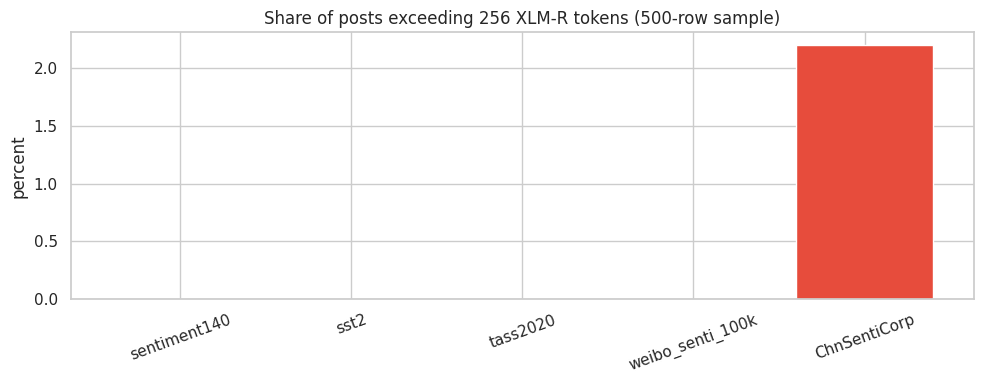

In [23]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
token_rows: list[dict[str, object]] = []

for name, bundle in loaded.items():
    spec = bundle["spec"]
    dataset = bundle["dataset"]
    stats = token_length_stats(
        dataset,
        text_column=spec.text_column,
        tokenizer=tokenizer,
        max_samples=500,
    )
    token_rows.append({"name": name, "language": spec.language, **stats})

token_summary = pl.DataFrame(token_rows).sort("language")
display(token_summary)

fig, ax = plt.subplots(figsize=(10, 4))
names = token_summary["name"].to_list()
pct_over = token_summary["pct_over_max_tokens"].to_list()
colors = [LANG_COLORS[lang] for lang in token_summary["language"].to_list()]
ax.bar(names, pct_over, color=colors, edgecolor="white")
ax.set_title(f"Share of posts exceeding {MAX_SEQUENCE_LENGTH} XLM-R tokens (500-row sample)")
ax.set_ylabel("percent")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 6. Cross-lingual length comparison

Stack all corpora into one frame and compare length distributions side by side.

Boxplots make it easy to see **median and spread** differences across languages — a preview of the domain mismatch we expect when Reddit study corpora (long-form) are scored with microblog-trained models.

Left panel: character length (fair for cross-lingual comparison). Right panel: word length (English/Spanish skew dominates).

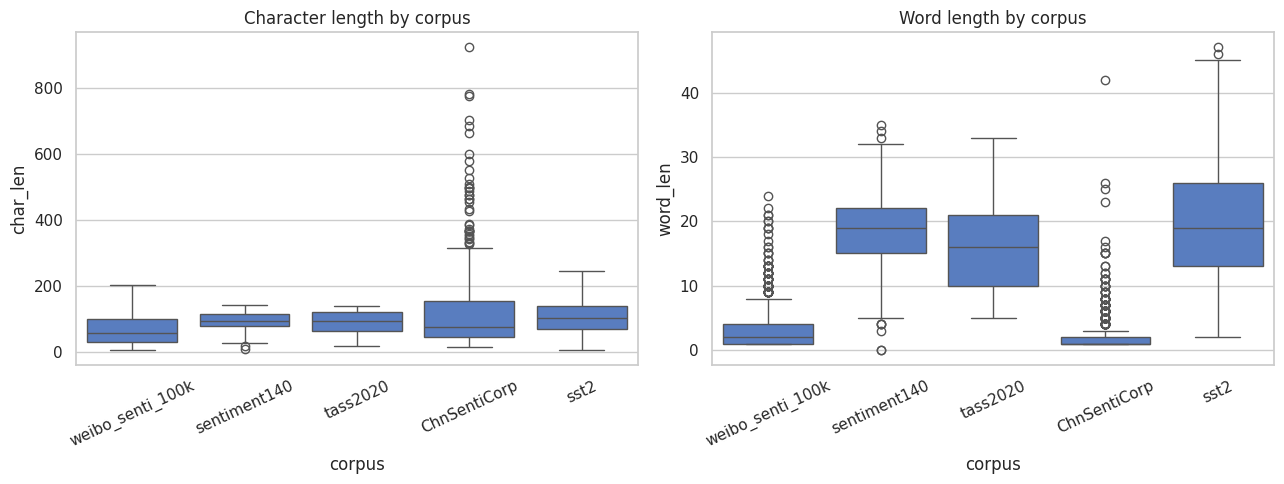

In [24]:
combined = pl.concat(
    [
        bundle["eda_frame"].with_columns(pl.lit(name).alias("corpus"))
        for name, bundle in loaded.items()
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=combined.to_pandas(), x="corpus", y="char_len", ax=axes[0])
axes[0].set_title("Character length by corpus")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(data=combined.to_pandas(), x="corpus", y="word_len", ax=axes[1])
axes[1].set_title("Word length by corpus")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## 7. Quality audit and harmonization flags

Rule-based checks on the summary table from Section 2. Each flag becomes a **preprocessing or data-pipeline task** for Phase 2.

Thresholds used:
- Label skew > 0.10 from 50/50
- Duplicate rate > 5%
- Any empty texts
- More than 5% of posts over 256 characters
- Known corpus-specific issues (e.g. string labels on sentiment140)

If no flags appear, the inspection sample passed all automated checks — manual spot-checks in Section 8 still apply.

In [25]:
flags: list[str] = []

for row in summary_rows:
    name = str(row["name"])
    if not row["is_binary"]:
        flags.append(f"**{name}**: not binary — map or filter labels before training.")
    if row["label_skew"] is not None and row["label_skew"] > 0.1:
        flags.append(
            f"**{name}**: label skew {row['label_skew']:.2f} "
            f"(positive ratio {row['positive_ratio']})."
        )
    if row["duplicate_rate"] > 0.05:
        flags.append(
            f"**{name}**: duplicate rate {row['duplicate_rate']:.1%} — dedup in preprocessing."
        )
    if row["empty_texts"]:
        flags.append(f"**{name}**: {row['empty_texts']} empty texts — drop before training.")
    if row["pct_over_char_256"] > 5:
        flags.append(
            f"**{name}**: {row['pct_over_char_256']}% posts exceed 256 chars — chunking required."
        )
    if name == "sentiment140":
        flags.append(
            "**sentiment140**: string labels (`negative`/`positive`) — map to `{0, 1}` in Phase 2."
        )

if flags:
    display(Markdown("\n".join(f"- {flag}" for flag in flags)))
else:
    display(Markdown("No harmonization flags raised on this inspection sample."))

- **sentiment140**: 2 empty texts — drop before training.
- **sentiment140**: string labels (`negative`/`positive`) — map to `{0, 1}` in Phase 2.
- **tass2020**: not binary — map or filter labels before training.
- **tass2020**: 4-class proxy — obtain official IberLEF/TASS 2020 and filter to NEG/POS.

## 8. Sample rows

Manual spot-check of three posts per corpus — sanity check for encoding, language, label semantics, and platform noise (e.g. Weibo moderation text, tweet handles).

Read these before trusting aggregate stats: one mislabeled or corrupted batch is easier to catch here than in a histogram.

In [26]:
for name, bundle in loaded.items():
    spec = bundle["spec"]
    dataset = bundle["dataset"]
    print("=" * 72)
    print(f"{name} | {spec.language} | {spec.role}")
    print(f"Source: {spec.hf_id}")
    display(sample_rows(dataset, spec.text_column, spec.label_column, n=3))

weibo_senti_100k | zh | train
Source: dirtycomputer/weibo_senti_100k


review,label
str,i64
"""淘宝卖家也有好人[嘻嘻]""",1
"""元芳，请问有治疗失眠的药方么？[抓狂][衰]""",0
"""拖...延...症...打这三个字都觉得好累...[汗]//…",0


sentiment140 | en | train
Source: Roh2014/sentiment140_10k_tweets


clean_tweet,sentiment
str,str
"""amazing day today car show wit…","""positive"""
"""homemade salmon ceaser salad f…","""positive"""
"""getting ready to go to a frien…","""negative"""


tass2020 | es | train
Source: mrm8488/tass-2019


sentence,labels
str,i64
"""@Tengo_Mas_Razon Mi país El pr…",2
"""Este año el Madrid hará triple…",1
"""@jose97angel ay, ayer cuando l…",3


ChnSentiCorp | zh | validation
Source: lansinuote/ChnSentiCorp


text,label
str,i64
"""AB型人看起来很混乱.很多时候自己也不知道在想些什么.这血型…",1
"""我的机子音箱听起来刺耳 跟手机喇叭似的 不知道其他人的怎样。…",0
"""首先我买是看了你们的评论才买的，我承认我上当了。书很薄，我以…",0


sst2 | en | validation
Source: nyu-mll/glue


sentence,label
str,i64
"""it gets onto the screen just a…",1
"""my big fat greek wedding uses …",1
"""for the most part , director a…",1


## Phase 1 takeaways

What we learned from this notebook:

- Inspection samples confirm schema and rough label balance across ZH/EN training and validation splits.
- Chinese text is much shorter in **word** count but comparable in **characters** — use token-level stats, not English word heuristics, for ZH.
- Phase 2 must harmonize labels to binary `{0: negative, 1: positive}` and chunk long Reddit study corpora to 256 XLM-R tokens.
- Spanish is zero-shot from XLM-R — no labeled ES training data. Manual spot-checks on peninsular Reddit corpora in Phase 2.